# Module 6 - Alzheimer's: Dimensionality Reduction (TruncatedSVD)

Complements module 1's UMAP + HDBSCAN. Here we use **TruncatedSVD** (essentially latent semantic analysis on the sparse binary report x reaction matrix), which is:
- Linear (unlike UMAP), so components are interpretable via their loadings
- Fast on sparse binary data
- The scikit-learn equivalent of correspondence analysis on standardized data

Compare the resulting 2D scatter to the drug-class overlay. If the classes visually separate on the first two components, the reaction profile alone fingerprints the class.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

## Step 1 - Build the sparse binary report x reaction matrix

In [2]:
top_reactions = pd.read_sql_query("""
    SELECT r.pt, COUNT(DISTINCT r.primaryid) AS n
    FROM reac r
    JOIN (SELECT DISTINCT primaryid FROM alzheimers_analysis) a
        ON r.primaryid = a.primaryid
    GROUP BY r.pt ORDER BY n DESC LIMIT 100
""", conn)['pt'].tolist()

placeholders = ','.join(['?'] * len(top_reactions))
pairs = pd.read_sql_query(f"""
    SELECT DISTINCT r.primaryid, r.pt
    FROM reac r
    JOIN (SELECT DISTINCT primaryid FROM alzheimers_analysis) a
        ON r.primaryid = a.primaryid
    WHERE r.pt IN ({placeholders})
""", conn, params=top_reactions)

X_df = (pairs.assign(present=1)
        .pivot_table(index='primaryid', columns='pt', values='present', fill_value=0))
print(f'Feature matrix: {X_df.shape}  (reports x reactions)')

Feature matrix: (1358, 100)  (reports x reactions)


## Step 2 - TruncatedSVD to 2D + drug-class overlay

Explained variance ratio: [0.075 0.051]  (sum = 0.126)


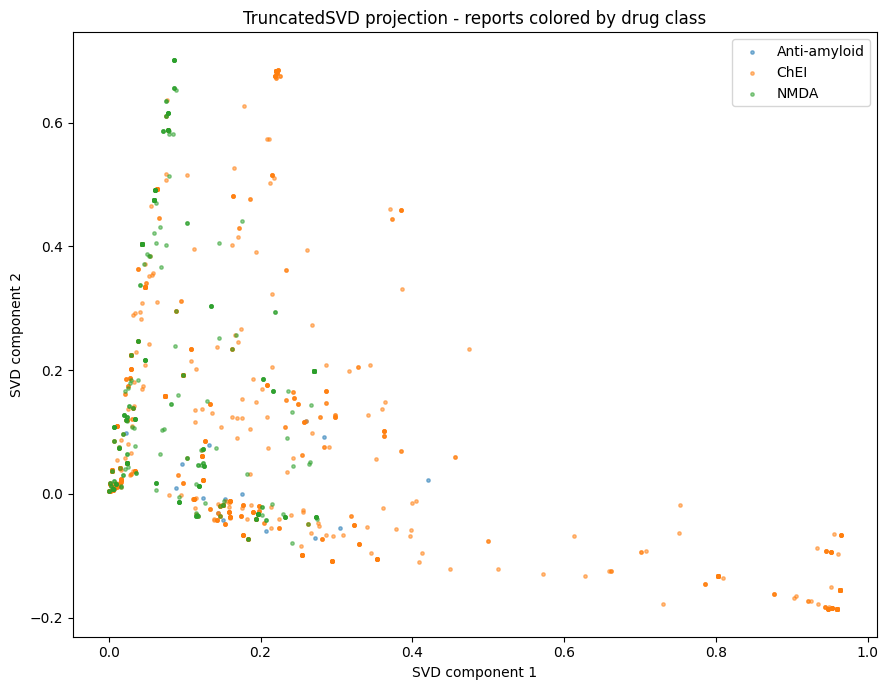

In [3]:
# Normalize rows to unit norm so overall report length doesn't dominate the projection.
X_norm = normalize(X_df.values, norm='l2', axis=1)

svd = TruncatedSVD(n_components=2, random_state=42)
proj = svd.fit_transform(X_norm)
print(f'Explained variance ratio: {svd.explained_variance_ratio_.round(3)}  '
      f'(sum = {svd.explained_variance_ratio_.sum():.3f})')

# Attach the drug class per primaryid
classes = pd.read_sql_query("""
    SELECT primaryid, MAX(drug_class) AS drug_class
    FROM alzheimers_analysis
    GROUP BY primaryid
""", conn).set_index('primaryid')

plot_df = pd.DataFrame({
    'svd_1': proj[:, 0],
    'svd_2': proj[:, 1],
    'primaryid': X_df.index,
}).merge(classes.reset_index(), on='primaryid', how='left')

fig, ax = plt.subplots(figsize=(9, 7))
for cls, sub in plot_df.dropna(subset=['drug_class']).groupby('drug_class'):
    ax.scatter(sub['svd_1'], sub['svd_2'], s=6, alpha=0.5, label=cls)
ax.legend()
ax.set_xlabel('SVD component 1')
ax.set_ylabel('SVD component 2')
ax.set_title('TruncatedSVD projection - reports colored by drug class')
plt.tight_layout()
plt.show()

## Step 3 - Interpret components via top loadings

In [4]:
# Which reactions drive each component? Highest-magnitude loadings on each axis.
loadings = pd.DataFrame(svd.components_.T,
                        index=X_df.columns,
                        columns=['component_1', 'component_2'])

for c in ['component_1', 'component_2']:
    print(f'\n=== {c}: top 8 |loadings| ===')
    print(loadings[c].abs().sort_values(ascending=False).head(8).round(3))


=== component_1: top 8 |loadings| ===
pt
Fall                   0.271
Dizziness              0.211
Fatigue                0.197
Diarrhoea              0.194
Haemorrhagic stroke    0.184
Tachycardia            0.176
Nausea                 0.174
Dyspnoea               0.161
Name: component_1, dtype: float64

=== component_2: top 8 |loadings| ===
pt
Off label use                 0.587
Drug ineffective              0.405
Toxicity to various agents    0.248
Overdose                      0.225
Fall                          0.198
Drug interaction              0.193
Sedation                      0.143
Cognitive disorder            0.140
Name: component_2, dtype: float64
